# Lecture 13 – Data Science


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings

## Multiple Linear Regression

Let's load in a new dataset. This is aggregate per-player data from the 2018-19 NBA season, downloaded from [Kaggle](https://www.kaggle.com/schmadam97/nba-regular-season-stats-20182019).

In [47]:
nba = pd.read_csv('nba18-19_lec12.csv', index_col=0)

nba.head(3)

,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,FG%,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
Rk,,,,,,,,,,,,,,,,,,,,,
1,Álex Abrines\abrinal01,SG,25,OKC,31,2,19.0,1.8,5.1,0.357,...,0.923,0.2,1.4,1.5,0.6,0.5,0.2,0.5,1.7,5.3
2,Quincy Acy\acyqu01,PF,28,PHO,10,0,12.3,0.4,1.8,0.222,...,0.700,0.3,2.2,2.5,0.8,0.1,0.4,0.4,2.4,1.7
3,Jaylen Adams\adamsja01,PG,22,ATL,34,1,12.6,1.1,3.2,0.345,...,0.778,0.3,1.4,1.8,1.9,0.4,0.1,0.8,1.3,3.2


In [48]:
# Drops name of index (players are ordered by rank)
df1=nba.reset_index()
df1.head(3)

,Rk,Player,Pos,Age,Tm,G,GS,MP,FG,FGA,...,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS
0,1,Álex Abrines\abrinal01,SG,25,OKC,31,2,19.0,1.8,5.1,...,0.923,0.2,1.4,1.5,0.6,0.5,0.2,0.5,1.7,5.3
1,2,Quincy Acy\acyqu01,PF,28,PHO,10,0,12.3,0.4,1.8,...,0.700,0.3,2.2,2.5,0.8,0.1,0.4,0.4,2.4,1.7
2,3,Jaylen Adams\adamsja01,PG,22,ATL,34,1,12.6,1.1,3.2,...,0.778,0.3,1.4,1.8,1.9,0.4,0.1,0.8,1.3,3.2


<br/>
We are interested in predicting the number of points (`PTS`) an athlete will score in a basketball game this season.

Suppose we want to fit a linear model by using some characteristics, or **feature**s of a player. Specifically, we'll focus on field goals, assists, and 3-point attempts.

- `FG`, the number of (2-point) field goals per game
- `AST`, the average number of assists per game, and
- `3PA`, the number of 3-point field goals attempted per game

This is how we express that model:

$$
\hat{y}
=
\theta_0 +
\theta_1 \cdot \textbf{FG} +
\theta_2 \cdot \textbf{AST} +
\theta_3 \cdot \textbf{3PA}
$$

In [49]:
# extract required Columns

df = df1[['FG','AST',"3PA"]]
df.head(3)

,FG,AST,3PA
0,1.8,0.6,4.1
1,0.4,0.8,1.5
2,1.1,1.9,2.2


<br/><br/>
In lecture, we saw that the predictions for the entire data set $\hat{\mathbb{Y}}$ can be computed as:

$$ \Large
\hat{\mathbb{Y}} = \mathbb{X} \theta  
$$

The **design matrix** $\mathbb{X} \in \mathbb{R}^{n,d+1}$ has $n$ rows corresponding to each record in the dataset and $d+1$ columns corresponding to the original $d$ columns in the data plus an additional 1s column vector (**bias/intercept feature**).

Let's build this design matrix using Pandas:

In [50]:
# insert bias term with dataframe
val=np.ones((708,1))
df.insert(0,"Bais",val)  
df.head(3)

,Bais,FG,AST,3PA
0,1.0,1.8,0.6,4.1
1,1.0,0.4,0.8,1.5
2,1.0,1.1,1.9,2.2


In [51]:
X=df.to_numpy()
X

array([[1. , 1.8, 0.6, 4.1],
       [1. , 0.4, 0.8, 1.5],
       [1. , 1.1, 1.9, 2.2],
       ...,
       [1. , 3.6, 1.1, 0. ],
       [1. , 3.4, 0.8, 0. ],
       [1. , 3.8, 1.5, 0. ]])

In [52]:
# the data shape
X.shape

(708, 4)

While we're at it, let's build the $\mathbb{Y}$ vector of our true `PTS` values.

In [53]:
# For nba data
y=np.array(df1['PTS']).reshape(len(df1['PTS']),1)
# how many observations
print(f'number of observations{len(y)}')
# visualize few
y[:5]



number of observations708


array([[ 5.3],
       [ 1.7],
       [ 3.2],
       [13.9],
       [ 8.9]])

In [54]:
y[0:5]

array([[ 5.3],
       [ 1.7],
       [ 3.2],
       [13.9],
       [ 8.9]])

---
## Example prediction

Suppose we decide to pick an arbitrary parameter $\theta$:

$$\theta = \begin{bmatrix}0.50 \\ -0.14 \\ 0.65 \\ 1.52 \end{bmatrix}$$

(For those interested: I drew these from random values simulated from a standard normal distribution using `np.random.randn`.)

In [55]:
theta_arbitrary = np.array([[0.5], [-1.14], [0.65], [1.52]])
theta_arbitrary

array([[ 0.5 ],
       [-1.14],
       [ 0.65],
       [ 1.52]])

For this value of $\theta$ we can make a prediction using our model with matrix multiplication.

The `@` symbol is the matrix multiply operation and is equivalent to writing `xt.dot(theta)`.

In [67]:
# apply the above random values on 'X' and predict 'y'

pred=X@theta_arbitrary
display(pred[:5])
y[:5]

array([ 5.07 ,  2.844,  3.825, -5.3  , -1.642])

array([[ 5.3],
       [ 1.7],
       [ 3.2],
       [13.9],
       [ 8.9]])

## Computing MSE

For Ordinary Least Squares, the average loss is MSE:

$$ \Large R(\theta) = \frac{1}{n} || \mathbb{Y} - \mathbb{X}\theta||^2_2 $$

NumPy has a handy function `np.linalg.norm` that computes the norm of a matrix (default is L2 norm).

In [70]:
theta_arbitrary = np.array([0.5, -1.14, 0.65, 1.52])
def mse_nba(theta):
    """
    Y is PTS
    X is intercept, FG, AST, 3PA
    """
    # compute MSE
    return (1/len(y)) * (np.linalg.norm(y- X@theta)**2)

mse_nba(theta_arbitrary)

57637.901845474524

Is this good? Is this bad? Let's compute the optimal theta and compare!

---
## Implementing Least Squares

From lecture, the Least Squares Estimate $\hat{\theta}$ is:
$$
\Large \hat{\theta} = \left( \mathbb{X}^{\top} \mathbb{X} \right)^{-1} \mathbb{X}^{\top} \mathbb{Y}
$$

While it is not as numerically stable or efficient. We can compute $\hat{\theta}$ by direction using matrix inversion. To do this, we import the `inv` function for the `numpy` linear algebra library:

In [71]:
from numpy.linalg import inv

In [72]:
X_T = X.T
X_T_X_I=np.linalg.inv(np.dot(X_T,X))
X_T_X_I

array([[ 4.75089865e-03, -6.76280879e-04, -1.54734319e-04,
        -3.76555371e-04],
       [-6.76280879e-04,  6.95107171e-04, -4.39064524e-04,
        -2.60833105e-04],
       [-1.54734319e-04, -4.39064524e-04,  9.59391151e-04,
        -9.68400502e-05],
       [-3.76555371e-04, -2.60833105e-04, -9.68400502e-05,
         5.31752770e-04]])

In [73]:
x_trans_y=np.dot(X.T,y)
x_trans_y

array([[ 5936.1 ],
       [26987.8 ],
       [15465.5 ],
       [20846.79]])

In [74]:
np.dot(X_T_X_I,x_trans_y)

array([[-0.29253798],
       [ 2.51705703],
       [ 0.05075571],
       [ 0.31307653]])

In [75]:
def least_squares_estimate(X, Y):
    # code here
    X_T = X.T
    X_T_X_I=np.linalg.inv(np.dot(X_T,X))
    
    x_trans_y=np.dot(X.T,y)
    
    theta_hat=np.dot(X_T_X_I,x_trans_y)
    
    return theta_hat

theta_hat = least_squares_estimate(X, y)
theta_hat

array([[-0.29253798],
       [ 2.51705703],
       [ 0.05075571],
       [ 0.31307653]])

In [98]:
print("Arbitrary theta MSE: ", mse_nba(theta_arbitrary))
print("Optimal theta MSE:"  , mse_nba(theta_hat))

Arbitrary theta MSE:  57637.901845474524
Optimal theta MSE: 0.3963133329080335


Nice!!!

---
## Making Least Squares Predictions

Now that we have estimated the model parameters $\hat{\theta}$ we can now also predict the points scored $\hat{\mathbb{Y}}$ for each of our players.

In [88]:
Y_hat = X @ theta_hat
Y_hat[:3]

array([[5.55223188],
       [1.2245042 ],
       [3.26142897]])

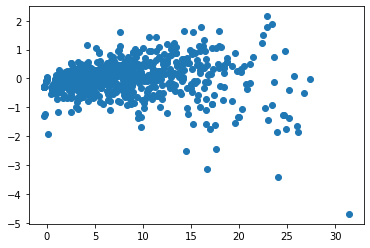

In [97]:
Y_hat- y
plt.scatter(Y_hat,Y_hat-y)

<br/>

---

## Model Performance/Diagnosing the Model

In previous lectures, we have plotted the residual vs. our single input feature $x$.

For higher dimensional regression models, we often graph the residual with respect to the fitted values $\hat{y}$.

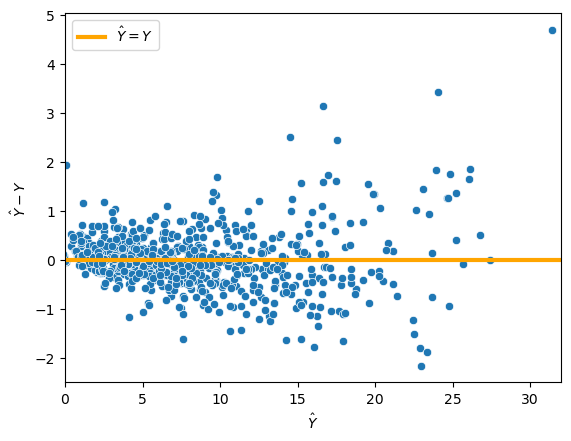

In [ ]:
# code here

Overall while the residuals are roughly centered around 0 ($\hat{y} = y$), we see **heteroskedasticity**: Our regression spread is uneven, particularly as predictions get big.

## Multiple $R^2$

Let's compute the coefficient of determination, or **multiple $R^2$**, for our model.

In [ ]:
# code here

0.9883162128703274

That's super high!!! Wait, what's up with that?

(Hint: Basketball facts)

Let's try reducing the number of features to see how this Multiple $R^2$ metric changes.

In [ ]:
# Use intercept, AST, 3PA


0.608786276366571

In [ ]:
# Use intercept, AST only (SLR)


0.4570055507968593

In [ ]:
theta_ast_only

array([[3.98332315],
       [2.39888152]])

In [ ]:
theta_hat

array([[-0.29253798],
       [ 2.51705703],
       [ 0.05075571],
       [ 0.31307653]])

Comparing these Multiple $R^2$ together:

In [ ]:
print("(SLR) intercept, AST:    ", r2_ast_only)
print("intercept, 3PA, AST:     ", r2_ast_3pa)
print("intercept, FG, 3PA, AST: ", r2_ast_fg_3pa)

(SLR) intercept, AST:     0.4570055507968593
intercept, 3PA, AST:      0.608786276366571
intercept, FG, 3PA, AST:  0.9883162128703274


Because of how basketball is scored, knowing Field Goals `FG` *and* 3 point goal attempts `3PA` will reliably tell you how many total points a player scored in that game. This is assuming NBA players make a good number of their 3 pointers.

Side note, if you wanted to check that Multiple R^2 for Simple Linear Regression is indeed correlation coefficient $r^2$:

In [ ]:
r = np.corrcoef(nba['AST'], nba['PTS'])[0,1]
r ** 2

0.4570055507968595

In [43]:
x=df
y=df1['PTS']

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [79]:
model=LinearRegression()

In [81]:
model.fit(x,y)

LinearRegression()

In [82]:
model.coef_

array([[0.        , 2.51705703, 0.05075571, 0.31307653]])

In [ ]:
[-0.29253798 , 2.51705703],
       [ 0.05075571],
       [ 0.31307653]

In [83]:
model.intercept_

array([-0.29253798])